*UCI Online Retail II — UK gift retailer, Dec 2009 to Dec 2011. Covers revenue trends, RFM segmentation, cohort retention, and simple CLV. Cleaned in Python, analysed in DuckDB SQL.*

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
path = "/content/drive/MyDrive/Data Projects/online_retail_II.xlsx"

df_09 = pd.read_excel(path, sheet_name="Year 2009-2010")
df_10 = pd.read_excel(path, sheet_name="Year 2010-2011")

In [3]:
print(f"df_09", df_09.shape)
print(f"df_10", df_10.shape)

df_09 (525461, 8)
df_10 (541910, 8)


In [4]:
df = pd.concat([df_09, df_10], ignore_index=True)
df.shape

(1067371, 8)

In [5]:
print("invoice count",df['Invoice'].count())
print("customer count",df['Customer ID'].count())


invoice count 1067371
customer count 824364


In [6]:
df=df.drop_duplicates().reset_index(drop=True)
df.shape

(1033036, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1033036 entries, 0 to 1033035
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1033036 non-null  object        
 1   StockCode    1033036 non-null  object        
 2   Description  1028761 non-null  object        
 3   Quantity     1033036 non-null  int64         
 4   InvoiceDate  1033036 non-null  datetime64[ns]
 5   Price        1033036 non-null  float64       
 6   Customer ID  797885 non-null   float64       
 7   Country      1033036 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 63.1+ MB


In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4275
Quantity,0
InvoiceDate,0
Price,0
Customer ID,235151
Country,0


In [9]:
df[df['Customer ID'].isna()]['Description'].isna().sum()

np.int64(4275)

*Dropped ~22.8% of rows — 235k missing Customer ID (no way to track behaviour), 4k missing Description. Rows with either null removed*

In [10]:
df = df.dropna(subset=['Customer ID', 'Description']).reset_index(drop=True)

df['Customer ID']=df['Customer ID'].astype(int)
df['Country']=df['Country'].astype('category')

In [11]:
print(df.isnull().sum())
print(df.info())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797885 entries, 0 to 797884
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  int64         
 7   Country      797885 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 43.4+ MB
None


*Deleted POST, M, D, ADJUST, DOT, CRUK. These are just fees/adjustments, not real sales. Kept PADS because it’s a real item*

In [12]:
service_fees = df[df['StockCode'].str.isalpha() == True]
print(service_fees[['StockCode', 'Description']].drop_duplicates())

       StockCode                          Description
89          POST                              POSTAGE
716            D                             Discount
2121           M                               Manual
42295       PADS           PADS TO MATCH ALL CUSHIONS
48957     ADJUST  Adjustment by john on 26/01/2010 16
49036     ADJUST  Adjustment by john on 26/01/2010 17
159489    ADJUST  Adjustment by Peter on 24/05/2010 1
624749       DOT                       DOTCOM POSTAGE
624750      CRUK                      CRUK Commission


In [13]:
noise_codes = ['POST', 'D', 'M', 'ADJUST', 'DOT', 'CRUK']

noise_rows = df[df['StockCode'].isin(noise_codes)]
print(f"Noise rows: {len(noise_rows)}")
print(f"Noise revenue: {(noise_rows['Quantity'] * noise_rows['Price']).sum():,.2f}")

Noise rows: 3331
Noise revenue: -82,136.97


In [14]:
df = df[~df['StockCode'].isin(noise_codes)].reset_index(drop=True)
df.shape

(794554, 8)

*Dropped ~2.22% cancellations (starting with 'C')*

invoice numbers with C don't always mirror the original — saw C102728 cancelling invoice 102727, sequential not matching. can't do matched-pair reconstruction with this data.

In [15]:
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"\nCancelled invoices: {len(cancelled)}")
print(f"Cancellation rate: {len(cancelled)/len(df)*100:.2f}%")

df = df[~df['Invoice'].astype(str).str.startswith('C')].reset_index(drop=True)
print(f"\nFinal clean rows: {len(df)}")


Cancelled invoices: 17603
Cancellation rate: 2.22%

Final clean rows: 776951


*63 rows with Price = 0 removed, including test entries and unpriced items*



In [16]:
print(df[df['Price'] == 0].shape)
print(df[df['Price'] < 0].shape)

print(df[df['Quantity'] <= 0].shape)

(63, 8)
(0, 8)
(0, 8)


In [17]:
print(df[df['Price'] == 0][['StockCode', 'Description', 'Quantity']].head(20))

       StockCode                        Description  Quantity
3563       22076                 6 RIBBONS EMPIRE          12
4673       48185                DOOR MAT FAIRY CAKE         2
13911      22065     CHRISTMAS PUDDING TRINKET POT          1
13912      22142       CHRISTMAS CRAFT WHITE FAIRY         12
23369      85042          ANTIQUE LILY FAIRY LIGHTS         8
28179      21143    ANTIQUE GLASS HEART DECORATION         12
32003      79320                    FLAMINGO LIGHTS        24
33118      22355        CHARLOTTE BAG , SUKI DESIGN        10
37754      21533          RETRO SPOT LARGE MILK JUG        12
60906    TEST001            This is a test product.         5
60994    TEST001            This is a test product.         5
78617      21662         VINTAGE GLASS COFFEE CADDY         1
107466     22459       CAST IRON HOOK GARDEN TROWEL         8
107467     22458         CAST IRON HOOK GARDEN FORK         8
120585     22376  AIRLINE BAG VINTAGE JET SET WHITE         1
172862  

In [18]:
df = df[df['Price'] > 0].reset_index(drop=True)
df['TotalPrice'] = df['Quantity'] * df['Price']
print(df.shape)
print(df['TotalPrice'].describe())

(776888, 9)
count    776888.000000
mean         21.988415
std         225.888967
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776888 entries, 0 to 776887
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      776888 non-null  object        
 1   StockCode    776888 non-null  object        
 2   Description  776888 non-null  object        
 3   Quantity     776888 non-null  int64         
 4   InvoiceDate  776888 non-null  datetime64[ns]
 5   Price        776888 non-null  float64       
 6   Customer ID  776888 non-null  int64         
 7   Country      776888 non-null  category      
 8   TotalPrice   776888 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 48.2+ MB


In [20]:
print(len(df[df['Country'] == 'Unspecified']))

518


In [21]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

**SQL ANALYSIS**

In [22]:
import duckdb

In [23]:
duckdb.sql("""
    SELECT * FROM df LIMIT 5
""").show()

┌─────────┬───────────┬─────────────────────────────────────┬──────────┬─────────────────────┬────────┬─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────┐
│ Invoice │ StockCode │             Description             │ Quantity │     InvoiceDate     │ Price  │ Customer ID │                                                                                                                                                                                                                                                 

518 rows have Country as 'Unspecified'. Left as-is — country isn't used in any of the four analyses.

In [24]:
duckdb.sql("""
  SELECT
    CAST(Country as Varchar) as Country,
    COUNT(*) as Count
  FROM df
  WHERE Country ILIKE 'Unspecified'
  GROUP BY Country
""").show()

┌─────────────┬───────┐
│   Country   │ Count │
│   varchar   │ int64 │
├─────────────┼───────┤
│ Unspecified │   518 │
└─────────────┴───────┘



**Revenue Analysis**

In [25]:
monthly_rev=duckdb.sql("""
  SELECT
    DATE_TRUNC('month',InvoiceDate) as month,
    ROUND(SUM(TotalPrice),2) as revenue
  FROM df
  GROUP BY month
  ORDER BY month
""").df()
monthly_rev

,month,revenue
0,2009-12-01,678394.57
1,2010-01-01,533952.98
2,2010-02-01,498152.58
3,2010-03-01,666373.67
4,2010-04-01,585544.93
5,2010-05-01,592964.13
6,2010-06-01,630020.45
7,2010-07-01,582207.96
8,2010-08-01,595141.17
9,2010-09-01,805974.81


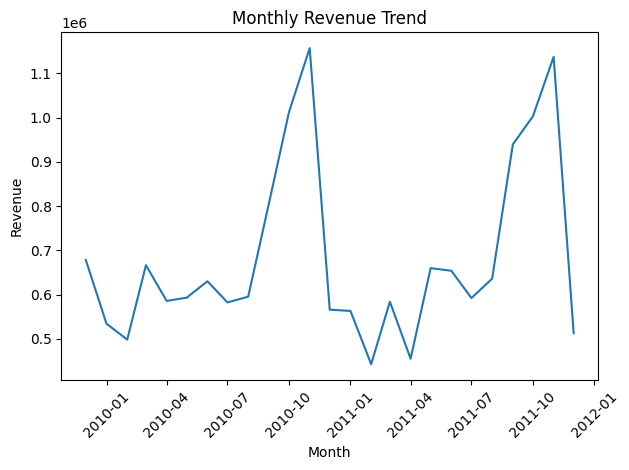

In [26]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(monthly_rev['month'], monthly_rev['revenue'])

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dec 2011 is incomplete — dataset ends 9th Dec. MoM drop of -54% is not a real decline

In [27]:
result=duckdb.sql("""
WITH monthly_rev AS (
  SELECT
    DATE_TRUNC('month',InvoiceDate) as month,
    ROUND(SUM(TotalPrice),2) as revenue
  FROM df
  WHERE InvoiceDate < '2011-12-01'
  GROUP BY month
)

SELECT
  month,
  revenue,
  ROUND((revenue-LAG(revenue) OVER(ORDER BY month))*100/LAG(revenue) OVER(ORDER BY month),2) as MoM
FROM monthly_rev
ORDER BY month
""").df()
result

,month,revenue,MoM
0,2009-12-01,678394.57,NaN
1,2010-01-01,533952.98,-21.29
2,2010-02-01,498152.58,-6.70
3,2010-03-01,666373.67,33.77
4,2010-04-01,585544.93,-12.13
5,2010-05-01,592964.13,1.27
6,2010-06-01,630020.45,6.25
7,2010-07-01,582207.96,-7.59
8,2010-08-01,595141.17,2.22
9,2010-09-01,805974.81,35.43


In [28]:
duckdb.sql("""
  SELECT
    EXTRACT(MONTH FROM InvoiceDate) as month,
    ROUND(SUM(TotalPrice),2) as revenue,
    ROUND(SUM(TotalPrice)*100/SUM(SUM(TotalPrice)) OVER(),2) AS rev_pct
  FROM df
  WHERE InvoiceDate < '2011-12-01'
  GROUP BY month
  ORDER BY month
""").show()

┌───────┬────────────┬─────────┐
│ month │  revenue   │ rev_pct │
│ int64 │   double   │ double  │
├───────┼────────────┼─────────┤
│     1 │ 1096850.89 │    6.62 │
│     2 │  940646.17 │    5.68 │
│     3 │ 1250217.52 │    7.55 │
│     4 │ 1040400.81 │    6.28 │
│     5 │ 1252657.62 │    7.56 │
│     6 │ 1283785.37 │    7.75 │
│     7 │ 1174311.75 │    7.09 │
│     8 │ 1231005.55 │    7.43 │
│     9 │ 1745657.44 │   10.53 │
│    10 │ 2015478.06 │   12.16 │
│    11 │ 2294972.39 │   13.85 │
│    12 │ 1244159.13 │    7.51 │
├───────┴────────────┴─────────┤
│ 12 rows            3 columns │
└──────────────────────────────┘



Peak revenue is driven strictly by transaction volume and customer frequency, as Median Order Value (MOV) remains stagnant at ~£300 year-round

In [29]:
monthly_trends = duckdb.sql("""
  WITH invoice_totals AS (
    SELECT
      Invoice,
      DATE_TRUNC('month', InvoiceDate) as month,
      SUM(TotalPrice) as invoice_sum,
      "Customer ID"
    FROM df
    WHERE InvoiceDate < '2011-12-01'
    GROUP BY Invoice, month, "Customer ID"
  ),
  customer_monthly_totals AS (
    SELECT
      month,
      "Customer ID",
      SUM(invoice_sum) as total_cust_spend
    FROM invoice_totals
    GROUP BY month, "Customer ID"
  ),
  monthly_metrics AS (
    SELECT
      i.month,
      SUM(i.invoice_sum) as total_revenue,
      COUNT(DISTINCT i.Invoice) as invoice_count,
      COUNT(DISTINCT i."Customer ID") as customer_count,
      MEDIAN(i.invoice_sum) as MOV,
      MEDIAN(c.total_cust_spend) as median_spend_per_cust
    FROM invoice_totals i
    JOIN customer_monthly_totals c ON i.month = c.month AND i."Customer ID" = c."Customer ID"
    GROUP BY i.month
  )

SELECT
  month,
  ROUND(total_revenue, 2) as revenue,
  ROUND(total_revenue / invoice_count, 2) as AOV,
  ROUND(MOV, 2) as MOV,
  ROUND(total_revenue / customer_count, 2) as avg_rev_per_cust,
  ROUND(median_spend_per_cust, 2) as median_rev_per_cust
FROM monthly_metrics
ORDER BY month
""").df()

monthly_trends

,month,revenue,AOV,MOV,avg_rev_per_cust,median_rev_per_cust
0,2009-12-01,678394.57,451.36,304.20,712.60,507.98
1,2010-01-01,533952.98,554.47,308.24,760.62,440.30
2,2010-02-01,498152.58,455.35,296.29,646.11,415.00
3,2010-03-01,666373.67,441.60,302.86,634.04,427.04
4,2010-04-01,585544.93,443.93,313.75,622.26,445.89
5,2010-05-01,592964.13,433.77,299.81,614.47,426.85
6,2010-06-01,630020.45,424.54,294.10,608.13,417.81
7,2010-07-01,582207.96,425.59,293.57,628.73,446.28
8,2010-08-01,595141.17,465.68,305.16,654.00,432.70
9,2010-09-01,805974.81,485.23,307.90,708.86,501.85


In [30]:
duckdb.sql("""
  WITH country_rev as (
    SELECT Country,
      SUM(TotalPrice) as revenue
    FROM df
    GROUP BY Country
  )
  SELECT
    CAST(Country AS VARCHAR) as Country,
    ROUND(revenue,2),
    ROUND(revenue*100.0/SUM(revenue) OVER(),2) as rev_contribution
  FROM country_rev
  ORDER BY rev_contribution DESC LIMIT 5
""")

┌────────────────┬───────────────────┬──────────────────┐
│    Country     │ round(revenue, 2) │ rev_contribution │
│    varchar     │      double       │      double      │
├────────────────┼───────────────────┼──────────────────┤
│ United Kingdom │       14293040.57 │            83.67 │
│ EIRE           │         595616.08 │             3.49 │
│ Netherlands    │         549773.41 │             3.22 │
│ Germany        │          383289.0 │             2.24 │
│ France         │         309799.16 │             1.81 │
└────────────────┴───────────────────┴──────────────────┘

In [31]:
duckdb.sql("""
WITH country_revenue as (
    SELECT
      Country,
      SUM(TotalPrice) AS Revenue
    FROM df
    GROUP BY Country
),
metrics as (
  SELECT Country,
    ROUND(Revenue,2) as revenue,
    ROUND(revenue*100.0/SUM(revenue) OVER(),2) as rev_contribution
  FROM country_revenue
)
SELECT
  Cast(Country as Varchar) as Country,
  revenue,
  rev_contribution
FROM metrics
WHERE Country!='United Kingdom'
ORDER BY revenue DESC
LIMIT 5
""").show()

┌─────────────┬───────────┬──────────────────┐
│   Country   │  revenue  │ rev_contribution │
│   varchar   │  double   │      double      │
├─────────────┼───────────┼──────────────────┤
│ EIRE        │ 595616.08 │             3.49 │
│ Netherlands │ 549773.41 │             3.22 │
│ Germany     │  383289.0 │             2.24 │
│ France      │ 309799.16 │             1.81 │
│ Australia   │ 167800.01 │             0.98 │
└─────────────┴───────────┴──────────────────┘



In [32]:
duckdb.sql("""
WITH invoice_totals AS (
    SELECT
        Invoice,
        "Customer ID",
        EXTRACT(year FROM InvoiceDate) as year,
        SUM(TotalPrice) as invoice_sum
    FROM df
    WHERE EXTRACT(month FROM InvoiceDate) != 12  -- Exclude Dec for YoY consistency
    GROUP BY Invoice, "Customer ID", year
)

SELECT
    year,
    ROUND(SUM(invoice_sum), 2) as revenue,
    COUNT(DISTINCT Invoice) as invoice_count,
    COUNT(DISTINCT "Customer ID") as cust_count,
    ROUND(AVG(invoice_sum), 2) as AOV,
    ROUND(MEDIAN(invoice_sum), 2) as MOV,
    ROUND(100 * (SUM(invoice_sum) - LAG(SUM(invoice_sum)) OVER (ORDER BY year)) /
          LAG(SUM(invoice_sum)) OVER (ORDER BY year), 2) as YoY_revenue
FROM invoice_totals
GROUP BY year
ORDER BY year
""").show()

┌───────┬────────────┬───────────────┬────────────┬────────┬────────┬─────────────┐
│ year  │  revenue   │ invoice_count │ cust_count │  AOV   │  MOV   │ YoY_revenue │
│ int64 │   double   │     int64     │   int64    │ double │ double │   double    │
├───────┼────────────┼───────────────┼────────────┼────────┼────────┼─────────────┤
│  2010 │ 7660062.57 │         16724 │       4128 │ 458.03 │ 303.64 │        NULL │
│  2011 │  7665921.0 │         16243 │       4168 │ 471.95 │ 303.01 │        0.08 │
└───────┴────────────┴───────────────┴────────────┴────────┴────────┴─────────────┘



In [33]:
duckdb.sql("""
WITH yearly_metrics as(
  SELECT
    EXTRACT(year FROM InvoiceDate) as year,
    ROUND(SUM(TotalPrice),2) as revenue,
    COUNT(DISTINCT EXTRACT(month FROM InvoiceDate)) as month_cnt,
    COUNT(DISTINCT Invoice) as invoice_count,
    COUNT(DISTINCT "Customer ID") as cust_count
  FROM df
  WHERE EXTRACT(month FROM InvoiceDate)!=12
  GROUP BY year
)

SELECT
  year,
  revenue,
  month_cnt,
  invoice_count,
  cust_count,
  ROUND(revenue / invoice_count, 2) AS aov,
  ROUND(100*(revenue-LAG(revenue) OVER(ORDER BY year))/LAG(revenue) OVER(ORDER BY year),2) as YoY
FROM yearly_metrics
ORDER BY year

""").show()

┌───────┬────────────┬───────────┬───────────────┬────────────┬────────┬────────┐
│ year  │  revenue   │ month_cnt │ invoice_count │ cust_count │  aov   │  YoY   │
│ int64 │   double   │   int64   │     int64     │   int64    │ double │ double │
├───────┼────────────┼───────────┼───────────────┼────────────┼────────┼────────┤
│  2010 │ 7660062.57 │        11 │         16724 │       4128 │ 458.03 │   NULL │
│  2011 │  7665921.0 │        11 │         16243 │       4168 │ 471.95 │   0.08 │
└───────┴────────────┴───────────┴───────────────┴────────────┴────────┴────────┘



**RFM ANALYSIS**

In [34]:
duckdb.sql("""
  SELECT
    CAST(MAX(InvoiceDate) AS DATE) as date
  FROM df
""").show()

┌────────────┐
│    date    │
│    date    │
├────────────┤
│ 2011-12-09 │
└────────────┘



Reference date is 2011-12-09 — last transaction date in dataset. Recency calculated as days since last purchase from this date.

In [35]:
rfm_df=duckdb.sql("""
  WITH cust_rfm AS(
    SELECT
      "Customer ID",
      DATEDIFF('day',CAST(MAX(InvoiceDate) AS DATE),'2011-12-09') AS recency,
      COUNT(DISTINCT Invoice) as frequency,
      ROUND(SUM(TotalPrice),2) as monetary
    FROM df
    GROUP BY "Customer ID"
  ),
  rfm_score AS(
    SELECT *,
      NTILE(5) OVER(ORDER BY recency DESC) AS r_score,
      NTILE(5) OVER(ORDER BY frequency ASC) AS f_score,
      NTILE(5) OVER(ORDER BY monetary ASC) AS m_score
    FROM cust_rfm
  )
SELECT *,
 CASE
    WHEN recency > 365 THEN 'Churned'
    WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions'
    WHEN r_score <= 2 AND f_score >= 3 AND m_score >= 3 THEN 'At-Risk'
    WHEN f_score <= 2 AND m_score >= 4 THEN 'Big Spenders'
    WHEN r_score >= 3 AND f_score >= 3 AND m_score >= 2 THEN 'Loyals'
    WHEN r_score >= 3 AND f_score <= 3 THEN 'Potential'
    ELSE 'Hibernating'
END AS segment
FROM rfm_score
""").df()
rfm_df.head()

,Customer ID,recency,frequency,monetary,r_score,f_score,m_score,segment
0,14095,722,1,2.95,1,1,1,Churned
1,13788,505,1,3.75,1,1,1,Churned
2,16738,297,1,3.75,2,1,1,Hibernating
3,14792,63,1,6.20,3,2,1,Potential
4,15913,534,1,6.30,1,1,1,Churned


In [36]:
duckdb.sql("""
    SELECT
        ROUND(AVG(recency), 1) AS avg_days,
        MEDIAN(recency) AS median_days,
        QUANTILE_CONT(recency, 0.25) AS p25_fast,
        QUANTILE_CONT(recency, 0.75) AS p75_slow,
        QUANTILE_CONT(recency, 0.90) AS p90_critical
    FROM rfm_df
""").show()

┌──────────┬─────────────┬──────────┬──────────┬──────────────┐
│ avg_days │ median_days │ p25_fast │ p75_slow │ p90_critical │
│  double  │   double    │  double  │  double  │    double    │
├──────────┼─────────────┼──────────┼──────────┼──────────────┤
│    199.7 │        95.0 │     25.0 │    379.0 │        530.0 │
└──────────┴─────────────┴──────────┴──────────┴──────────────┘



In [37]:
duckdb.sql("""
  SELECT
    segment,
    "Customer ID",
    monetary,
    recency,
    CASE
      WHEN recency <= 25 THEN 'Active (Top 25%)'
      WHEN recency <= 95 THEN 'Active (Median)'
      ELSE 'Lapsed'
    END AS activity_status
  FROM rfm_df
  ORDER BY monetary DESC
  LIMIT 10
""").show()



┌───────────┬─────────────┬───────────┬─────────┬──────────────────┐
│  segment  │ Customer ID │ monetary  │ recency │ activity_status  │
│  varchar  │    int64    │  double   │  int64  │     varchar      │
├───────────┼─────────────┼───────────┼─────────┼──────────────────┤
│ Champions │       18102 │ 580987.04 │       0 │ Active (Top 25%) │
│ Champions │       14646 │ 526751.52 │       1 │ Active (Top 25%) │
│ Champions │       14156 │ 304719.88 │       9 │ Active (Top 25%) │
│ Champions │       14911 │ 279492.79 │       1 │ Active (Top 25%) │
│ Champions │       17450 │ 244784.25 │       8 │ Active (Top 25%) │
│ Champions │       13694 │ 195640.69 │       3 │ Active (Top 25%) │
│ Champions │       17511 │ 172132.87 │       2 │ Active (Top 25%) │
│ Loyals    │       16446 │  168472.5 │       0 │ Active (Top 25%) │
│ Champions │       16684 │ 147142.77 │       4 │ Active (Top 25%) │
│ Champions │       12415 │ 144033.37 │      24 │ Active (Top 25%) │
├───────────┴─────────────┴───────

Champions and Loyals generate 85% of total revenue despite being only 46% of the customer base. This small group generates over 5.6x the value of all other segments combined.

In [38]:
seg_summary_df=duckdb.sql("""
  SELECT
    segment,
    COUNT(*) AS cust_count,
    ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),2) AS pct_cust,
    ROUND(SUM(monetary), 2) AS total_revenue,
    ROUND(SUM(monetary) * 100.0 / SUM(SUM(monetary)) OVER(), 2) AS pct_revenue,
    ROUND(SUM(monetary) / COUNT(*), 2) AS rev_per_cust,
    ROUND(AVG(frequency), 2) AS avg_frequency,
    ROUND(SUM(monetary) / SUM(frequency), 2) AS aov,
FROM rfm_df
GROUP BY segment
ORDER BY total_revenue DESC
""").df()
seg_summary_df

,segment,cust_count,pct_cust,total_revenue,pct_revenue,rev_per_cust,avg_frequency,aov
0,Champions,1330,22.72,11725399.70,68.64,8816.09,16.56,532.44
1,Loyals,1401,23.94,2779637.87,16.27,1984.04,5.31,373.31
2,Churned,1582,27.03,1217398.06,7.13,769.53,2.21,348.03
3,At-Risk,295,5.04,790788.21,4.63,2680.64,6.01,445.77
4,Potential,733,12.52,267435.23,1.57,364.85,1.40,260.40
5,Hibernating,449,7.67,168003.12,0.98,374.17,1.72,217.06
6,Big Spenders,63,1.08,133873.58,0.78,2124.98,1.62,1312.49


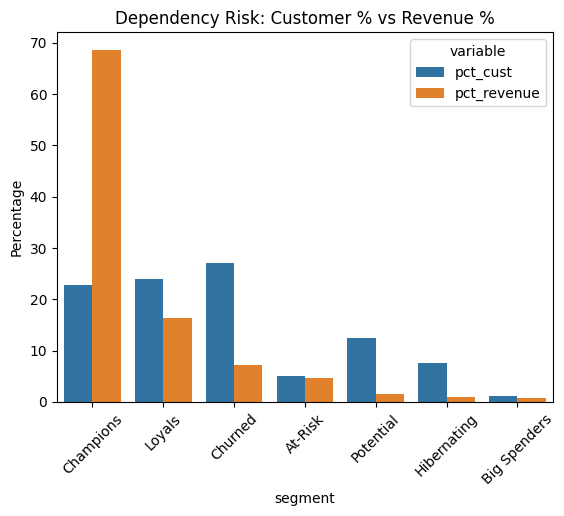

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = seg_summary_df.melt(id_vars='segment', value_vars=['pct_cust', 'pct_revenue'])

sns.barplot(data=plot_data, x='segment', y='value', hue='variable')

plt.title('Dependency Risk: Customer % vs Revenue %')
plt.xticks(rotation=45)
plt.ylabel('Percentage')
plt.show()

Losing just 10% of our Champions will result in an immediate revenue drop of £1174022.68, an amount larger than the total combined revenue of our Potential and Hibernating segments.

In [40]:
duckdb.sql("""
  SELECT
  ROUND(SUM(CASE WHEN segment = 'Champions' THEN monetary END) * 0.10, 2) AS loss_10pct_champions,

  ROUND(
    SUM(CASE WHEN segment = 'Champions' THEN monetary END) * 0.10
    / SUM(monetary) * 100, 2
  ) AS pct_total_revenue_loss

FROM rfm_df;
""").show()

┌──────────────────────┬────────────────────────┐
│ loss_10pct_champions │ pct_total_revenue_loss │
│        double        │         double         │
├──────────────────────┼────────────────────────┤
│           1172539.97 │                   6.86 │
└──────────────────────┴────────────────────────┘



By migrating just 20% of Loyal customers to Champion spending levels, we can drive a 69% revenue lift (£1.92M) for the entire segment.

In [41]:
duckdb.sql("""
  WITH champion_metric AS (
    SELECT rev_per_cust FROM seg_summary_df WHERE segment = 'Champions'
  ),
  loyal_metric AS (
    SELECT cust_count, total_revenue FROM seg_summary_df WHERE segment = 'Loyals'
  )
  SELECT
    l.cust_count AS loyal_count,
    l.total_revenue AS current_loyal_rev,
    ROUND((l.cust_count * 0.2) * c.rev_per_cust, 2) AS potential_rev,
    ROUND(((l.cust_count * 0.2) * c.rev_per_cust) - (l.total_revenue * 0.2), 2) AS revenue_gap
FROM champion_metric c,loyal_metric l;
""")

┌─────────────┬───────────────────┬───────────────┬─────────────┐
│ loyal_count │ current_loyal_rev │ potential_rev │ revenue_gap │
│    int64    │      double       │    double     │   double    │
├─────────────┼───────────────────┼───────────────┼─────────────┤
│        1401 │        2779637.87 │    2470268.42 │  1914340.84 │
└─────────────┴───────────────────┴───────────────┴─────────────┘

Revenue is extremely concentrated — while 23% of customers drive 80% of revenue, the bottom 30% contribute just 2.3%, revealing a highly skewed value distribution.

In [42]:
duckdb.sql("""
  WITH customer_ranks AS (
    SELECT
        "Customer ID",
        monetary,
        SUM(monetary) OVER (ORDER BY monetary DESC) as running_rev,
        SUM(monetary) OVER () as grand_total
    FROM rfm_df
),
revenue_threshold AS (
    SELECT
        "Customer ID"
    FROM customer_ranks
    WHERE running_rev <= (grand_total * 0.80)
)
SELECT
    COUNT(*) AS customer_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM rfm_df), 2) AS pct_of_base
FROM revenue_threshold;
""")

┌────────────────┬─────────────┐
│ customer_count │ pct_of_base │
│     int64      │   double    │
├────────────────┼─────────────┤
│           1352 │        23.1 │
└────────────────┴─────────────┘

VIP Retention: 55 'At-Risk' high-spenders represent £467k in revenue. With a median value of £4,417 per customer, these individual accounts are high-priority targets currently nearing churn.

In [43]:
duckdb.sql("""
SELECT
    COUNT(*) AS at_risk_count,
    ROUND(SUM(monetary), 2) AS endangered_revenue,
    ROUND(MEDIAN(monetary), 2) AS median_monetary,
    ROUND(AVG(recency), 0) AS avg_days_since_last_purchase,
    ROUND(SUM(monetary) * 100.0 / (SELECT SUM(monetary) FROM rfm_df), 2) AS pct_of_total_revenue
FROM rfm_df
WHERE segment = 'At-Risk'
  AND monetary > (SELECT AVG(monetary) FROM rfm_df);
""").show()

┌───────────────┬────────────────────┬─────────────────┬──────────────────────────────┬──────────────────────┐
│ at_risk_count │ endangered_revenue │ median_monetary │ avg_days_since_last_purchase │ pct_of_total_revenue │
│     int64     │       double       │     double      │            double            │        double        │
├───────────────┼────────────────────┼─────────────────┼──────────────────────────────┼──────────────────────┤
│            55 │          466812.14 │         4417.27 │                        258.0 │                 2.73 │
└───────────────┴────────────────────┴─────────────────┴──────────────────────────────┴──────────────────────┘



Customer base is split almost evenly — 28% bought within 30 days, 27% haven't bought in over a year. Retention is the core problem.

In [44]:
duckdb.sql("""
  SELECT
    CASE
      WHEN recency <= 30 THEN '0-30 days'
      WHEN recency <= 90 THEN '31-90 days'
      WHEN recency <= 180 THEN '91-180 days'
      WHEN recency <= 365 THEN '181-365 days'
      ELSE '365+ days'
    END AS recency_bucket,
    COUNT(*) AS cust_count,
    ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),2) AS pct
  FROM rfm_df
  GROUP BY recency_bucket
  ORDER BY MIN(recency)
""").show()

┌────────────────┬────────────┬────────┐
│ recency_bucket │ cust_count │  pct   │
│    varchar     │   int64    │ double │
├────────────────┼────────────┼────────┤
│ 0-30 days      │       1666 │  28.46 │
│ 31-90 days     │       1220 │  20.84 │
│ 91-180 days    │        589 │  10.06 │
│ 181-365 days   │        796 │   13.6 │
│ 365+ days      │       1582 │  27.03 │
└────────────────┴────────────┴────────┘



**COHORT ANALYSIS**

In [45]:
cohort_df = duckdb.sql("""
  WITH customer_cohort AS (
    SELECT
      "Customer ID",
      DATE_TRUNC('month', MIN(InvoiceDate)) AS cohort_month
    FROM df
    GROUP BY "Customer ID"
  ),
  monthly_activity AS (
    SELECT
      d."Customer ID",
      DATE_TRUNC('month', d.InvoiceDate) AS activity_month
    FROM df d
    GROUP BY d."Customer ID", activity_month
  )
  SELECT
    c.cohort_month,
    a.activity_month,
    DATEDIFF('month', c.cohort_month, a.activity_month) AS period,
    COUNT(DISTINCT a."Customer ID") AS cust_count
  FROM customer_cohort c
  JOIN monthly_activity a ON c."Customer ID" = a."Customer ID"
  GROUP BY c.cohort_month, a.activity_month
  ORDER BY c.cohort_month, period
""").df()
cohort_df.head()

,cohort_month,activity_month,period,cust_count
0,2009-12-01,2009-12-01,0,952
1,2009-12-01,2010-01-01,1,334
2,2009-12-01,2010-02-01,2,317
3,2009-12-01,2010-03-01,3,405
4,2009-12-01,2010-04-01,4,362


In [46]:
cohort_retention_df = duckdb.sql("""
  WITH cohort_size AS (
    SELECT cohort_month, cust_count AS total_customers
    FROM cohort_df WHERE period = 0
  )
  SELECT
    c.cohort_month,
    c.period,
    c.cust_count,
    cs.total_customers,
    ROUND(c.cust_count * 100.0 / cs.total_customers, 2) AS retention_rate
  FROM cohort_df c
  JOIN cohort_size cs ON c.cohort_month = cs.cohort_month
  ORDER BY c.cohort_month, c.period
""").df()
cohort_retention_df.head()

,cohort_month,period,cust_count,total_customers,retention_rate
0,2009-12-01,0,952,952,100.00
1,2009-12-01,1,334,952,35.08
2,2009-12-01,2,317,952,33.30
3,2009-12-01,3,405,952,42.54
4,2009-12-01,4,362,952,38.03


Peak months drive high acquisition, but retention is purely seasonal—customers buy frequently during the holidays then vanish until the following year.

In [47]:
cohort_view=duckdb.sql("""
  SELECT
    STRFTIME(cohort_month :: DATE, '%Y-%m') AS cohort,
    total_customers AS acquired,
    MAX(CASE WHEN period = 1 THEN retention_rate END) AS month_1,
    MAX(CASE WHEN period = 3 THEN retention_rate END) AS month_3,
    MAX(CASE WHEN period = 6 THEN retention_rate END) AS month_6,
    MAX(CASE WHEN period = 12 THEN retention_rate END) AS month_12
  FROM cohort_retention_df
  GROUP BY cohort_month, total_customers
  ORDER BY cohort_month
""").df()
cohort_view

,cohort,acquired,month_1,month_3,month_6,month_12
0,2009-12,952,35.08,42.54,37.82,37.71
1,2010-01,368,21.47,31.52,26.90,22.83
2,2010-02,375,23.47,29.33,19.20,15.20
3,2010-03,440,19.09,24.09,25.00,20.00
4,2010-04,294,19.05,15.99,27.55,14.29
5,2010-05,255,15.69,17.65,21.18,15.29
6,2010-06,267,17.60,20.60,12.73,14.98
7,2010-07,186,15.59,29.57,11.29,12.90
8,2010-08,163,19.63,32.52,9.82,14.72
9,2010-09,239,23.01,12.97,13.81,22.59


Long-term retention declined sharply after early cohorts, with only partial recovery during late 2010 peak months.

In [48]:
duckdb.sql("""
  SELECT
    STRFTIME(cohort_month :: DATE, '%Y-%m') AS cohort,
    total_customers AS acquired,
    MAX(CASE WHEN period = 6 THEN cust_count END) AS surviving_6m,
    MAX(CASE WHEN period = 12 THEN cust_count END) AS surviving_12m,
    ROUND(MAX(CASE WHEN period = 6 THEN cust_count END) * 100.0 / total_customers, 2) AS retention_pct_6m,
    ROUND(MAX(CASE WHEN period = 12 THEN cust_count END) * 100.0 / total_customers, 2) AS retention_pct_12m
  FROM cohort_retention_df
  WHERE cohort_month <= '2010-12-01'
  GROUP BY cohort_month, total_customers
  ORDER BY cohort_month
""").show()

┌─────────┬──────────┬──────────────┬───────────────┬──────────────────┬───────────────────┐
│ cohort  │ acquired │ surviving_6m │ surviving_12m │ retention_pct_6m │ retention_pct_12m │
│ varchar │  int64   │    int64     │     int64     │      double      │      double       │
├─────────┼──────────┼──────────────┼───────────────┼──────────────────┼───────────────────┤
│ 2009-12 │      952 │          360 │           359 │            37.82 │             37.71 │
│ 2010-01 │      368 │           99 │            84 │             26.9 │             22.83 │
│ 2010-02 │      375 │           72 │            57 │             19.2 │              15.2 │
│ 2010-03 │      440 │          110 │            88 │             25.0 │              20.0 │
│ 2010-04 │      294 │           81 │            42 │            27.55 │             14.29 │
│ 2010-05 │      255 │           54 │            39 │            21.18 │             15.29 │
│ 2010-06 │      267 │           34 │            40 │            12.73

In [49]:
duckdb.sql("""
WITH cohort_birth AS (
    SELECT
        "Customer ID",
        DATE_TRUNC('month', MIN(InvoiceDate)) AS cohort_month
    FROM df
    GROUP BY 1
),
segment_distribution AS (
    SELECT
        cb.cohort_month,
        r.segment,
        COUNT(cb."Customer ID") as cust_count
    FROM cohort_birth cb
    JOIN rfm_df r ON cb."Customer ID" = r."Customer ID"
    WHERE cb.cohort_month < '2011-09-01'
    GROUP BY 1, 2
),
cohort_totals AS (
    SELECT
        cohort_month,
        SUM(cust_count) as total_acquired
    FROM segment_distribution
    GROUP BY 1
)
SELECT
    t.cohort_month,
    t.total_acquired,
    ROUND(SUM(CASE WHEN s.segment = 'Champions' THEN s.cust_count ELSE 0 END) * 100.0 / t.total_acquired, 2) AS champions_pct,
    ROUND(SUM(CASE WHEN s.segment = 'Loyals' THEN s.cust_count ELSE 0 END) * 100.0 / t.total_acquired, 2) AS loyal_pct,
    ROUND(SUM(CASE WHEN s.segment = 'Big Spenders' THEN s.cust_count ELSE 0 END) * 100.0 / t.total_acquired, 2) AS bigspender_pct,
    ROUND(SUM(CASE WHEN s.segment = 'Potential' THEN s.cust_count ELSE 0 END) * 100.0 / t.total_acquired, 2) AS potential_pct,

    ROUND(SUM(CASE WHEN s.segment = 'At-Risk' THEN s.cust_count ELSE 0 END) * 100.0 / t.total_acquired, 2) AS at_risk_pct,
    ROUND(SUM(CASE WHEN s.segment = 'Hibernating' THEN s.cust_count ELSE 0 END) * 100.0 / t.total_acquired, 2) AS hibernating_pct,
    ROUND(SUM(CASE WHEN s.segment = 'Churned' THEN s.cust_count ELSE 0 END) * 100.0 / t.total_acquired, 2) AS churned_pct
FROM cohort_totals t
JOIN segment_distribution s ON t.cohort_month = s.cohort_month
GROUP BY 1, 2
ORDER BY 1
""").show()

┌──────────────┬────────────────┬───────────────┬───────────┬────────────────┬───────────────┬─────────────┬─────────────────┬─────────────┐
│ cohort_month │ total_acquired │ champions_pct │ loyal_pct │ bigspender_pct │ potential_pct │ at_risk_pct │ hibernating_pct │ churned_pct │
│     date     │     int128     │    double     │  double   │     double     │    double     │   double    │     double      │   double    │
├──────────────┼────────────────┼───────────────┼───────────┼────────────────┼───────────────┼─────────────┼─────────────────┼─────────────┤
│ 2009-12-01   │            952 │         47.58 │     17.86 │           0.11 │          0.63 │        7.56 │            1.47 │       24.79 │
│ 2010-01-01   │            368 │         29.89 │     24.73 │           0.27 │          0.82 │       11.68 │            1.09 │       31.52 │
│ 2010-02-01   │            375 │         22.93 │      28.0 │           0.27 │          0.53 │        8.53 │            3.47 │       36.27 │
│ 2010-03-01 

Customer conversion quality declined through 2010, with peak revenue months producing the lowest conversion rates, while 2011 cohorts show a growing pool of unconverted “potential” customers, indicating delayed rather than reduced customer value.

In [50]:
duckdb.sql("""
WITH cohort_birth AS (
    SELECT
        "Customer ID",
        DATE_TRUNC('month', MIN(InvoiceDate)) AS cohort_month
    FROM df
    GROUP BY 1
)
SELECT
    cb.cohort_month,
    COUNT(cb."Customer ID") AS total_acquired,
    SUM(CASE WHEN r.segment = 'Champions' THEN 1 ELSE 0 END) AS current_champions,
    SUM(CASE WHEN r.segment = 'Potential' THEN 1 ELSE 0 END) AS currently_potential,
    ROUND(SUM(CASE WHEN r.segment = 'Champions' THEN 1 ELSE 0 END) * 100.0 / COUNT(cb."Customer ID"), 2) AS conversion_to_champion_pct
FROM cohort_birth cb
JOIN rfm_df r ON cb."Customer ID" = r."Customer ID"
WHERE cb.cohort_month >= '2010-01-01' AND cb.cohort_month < '2011-09-01'
GROUP BY 1
ORDER BY 1
""").show()

┌──────────────┬────────────────┬───────────────────┬─────────────────────┬────────────────────────────┐
│ cohort_month │ total_acquired │ current_champions │ currently_potential │ conversion_to_champion_pct │
│     date     │     int64      │      int128       │       int128        │           double           │
├──────────────┼────────────────┼───────────────────┼─────────────────────┼────────────────────────────┤
│ 2010-01-01   │            368 │               110 │                   3 │                      29.89 │
│ 2010-02-01   │            375 │                86 │                   2 │                      22.93 │
│ 2010-03-01   │            440 │               110 │                  10 │                       25.0 │
│ 2010-04-01   │            294 │                70 │                   5 │                      23.81 │
│ 2010-05-01   │            255 │                41 │                  10 │                      16.08 │
│ 2010-06-01   │            267 │                49 │  

In [51]:
duckdb.sql("""
WITH customer_activity AS (
    SELECT
        "Customer ID",
        DATE_TRUNC('month', MIN(InvoiceDate)) AS cohort_month,
        SUM(TotalPrice) AS customer_lifetime_revenue,
        COUNT(DISTINCT Invoice) AS transaction_count
    FROM df
    GROUP BY 1
)
SELECT
    cohort_month,
    COUNT("Customer ID") AS total_customers,

    ROUND(SUM(customer_lifetime_revenue), 2) AS total_revenue,
    ROUND(AVG(customer_lifetime_revenue), 2) AS rpu,
    ROUND(MEDIAN(customer_lifetime_revenue), 2) AS median_revenue,

    ROUND(AVG(transaction_count), 2) AS avg_trans_freq,
    ROUND(MEDIAN(transaction_count), 2) AS median_trans_freq
FROM customer_activity
WHERE cohort_month < '2011-09-01'
GROUP BY 1
ORDER BY 1
""").show()

┌──────────────┬─────────────────┬───────────────┬─────────┬────────────────┬────────────────┬───────────────────┐
│ cohort_month │ total_customers │ total_revenue │   rpu   │ median_revenue │ avg_trans_freq │ median_trans_freq │
│     date     │      int64      │    double     │ double  │     double     │     double     │      double       │
├──────────────┼─────────────────┼───────────────┼─────────┼────────────────┼────────────────┼───────────────────┤
│ 2009-12-01   │             952 │    8399900.54 │ 8823.42 │        2821.24 │          15.96 │               9.0 │
│ 2010-01-01   │             368 │    1278846.66 │ 3475.13 │        1858.94 │           8.41 │               6.0 │
│ 2010-02-01   │             375 │     975848.94 │ 2602.26 │        1322.07 │            6.7 │               5.0 │
│ 2010-03-01   │             440 │    1218748.51 │ 2769.88 │        1269.81 │           6.54 │               4.0 │
│ 2010-04-01   │             294 │     536172.99 │ 1823.72 │        1099.28 │   

In [52]:
duckdb.sql("""
WITH customer_cohort AS (
    SELECT "Customer ID",
    DATE_TRUNC('month', MIN(InvoiceDate)) AS cohort_month,
    FROM df
    GROUP BY 1
),
activity_90d AS (
    SELECT
        cc."Customer ID",
        cohort_month,
        COUNT(DISTINCT d.Invoice) as txn_count
    FROM customer_cohort cc
    JOIN df d ON cc."Customer ID" = d."Customer ID"
    WHERE d.InvoiceDate <= cc.cohort_month + INTERVAL '90 days'
    GROUP BY 1, 2
)
SELECT
    cohort_month,
    COUNT("Customer ID") as total_acquired,
    ROUND(AVG(CASE WHEN txn_count >= 3 THEN 1 ELSE 0 END) * 100, 2) as speed_to_loyalty_pct
FROM activity_90d
WHERE cohort_month < '2011-09-01'
GROUP BY 1
ORDER BY 1
""").show()

┌──────────────┬────────────────┬──────────────────────┐
│ cohort_month │ total_acquired │ speed_to_loyalty_pct │
│     date     │     int64      │        double        │
├──────────────┼────────────────┼──────────────────────┤
│ 2009-12-01   │            952 │                34.14 │
│ 2010-01-01   │            368 │                21.47 │
│ 2010-02-01   │            375 │                 16.0 │
│ 2010-03-01   │            440 │                15.68 │
│ 2010-04-01   │            294 │                12.93 │
│ 2010-05-01   │            255 │                 9.02 │
│ 2010-06-01   │            267 │                14.98 │
│ 2010-07-01   │            186 │                16.67 │
│ 2010-08-01   │            163 │                14.72 │
│ 2010-09-01   │            239 │                17.57 │
│ 2010-10-01   │            375 │                17.07 │
│ 2010-11-01   │            326 │                12.27 │
│ 2010-12-01   │             76 │                 5.26 │
│ 2011-01-01   │             72

Dec 2009 cohort strongest throughout — earliest customers stayed longest. Dec 2010 worst at 2.63% by month 12, likely one-time gift buyers. retention settles around 15-21% after month 7 — whoever stays past that tends to stick around.

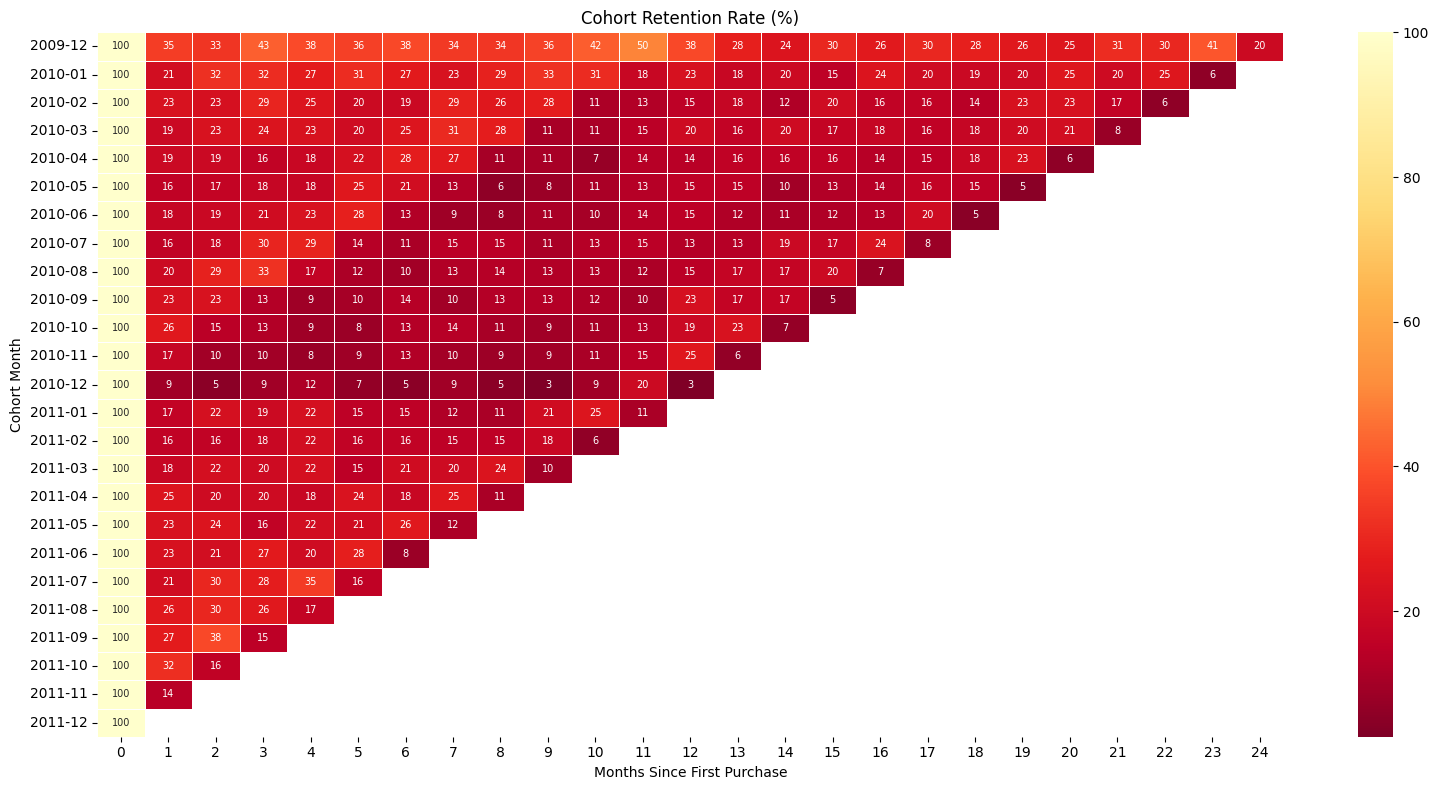

In [53]:
import seaborn as sns

cohort_pivot = cohort_retention_df.pivot_table(
    index='cohort_month',
    columns='period',
    values='retention_rate'
)

cohort_pivot.index = cohort_pivot.index.astype(str).str[:7]

plt.figure(figsize=(16, 8))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('Cohort Retention Rate (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

**Simple CLV — median order value × monthly purchase rate × 12**

In [54]:
clv_df = duckdb.sql("""
  WITH invoice_totals AS (
    SELECT
      "Customer ID",
      Invoice,
      SUM(TotalPrice) AS invoice_spend,
      MIN(InvoiceDate) AS InvoiceDate
    FROM df
    GROUP BY "Customer ID", Invoice
  ),
  customer_metrics AS (
    SELECT
      "Customer ID",
      COUNT(DISTINCT Invoice) AS total_orders,
      ROUND(SUM(invoice_spend), 2) AS total_revenue,
      ROUND(MEDIAN(invoice_spend), 2) AS med_order_value,
      GREATEST(DATEDIFF('month', CAST(MIN(InvoiceDate) AS DATE), DATE '2011-12-09'), 1) AS active_months
    FROM invoice_totals
    GROUP BY "Customer ID"
  ),
  customer_clv AS (
    SELECT
      c."Customer ID",
      r.segment,
      c.total_orders,
      c.total_revenue,
      c.med_order_value,
      c.active_months,
      ROUND(c.total_orders * 1.0 / c.active_months, 2) AS purchase_rate
    FROM customer_metrics c
    JOIN rfm_df r ON c."Customer ID" = r."Customer ID"
  )
  SELECT *,
    ROUND(med_order_value * purchase_rate * 12, 2) AS clv_12m
  FROM customer_clv
""").df()

clv_df

,Customer ID,segment,total_orders,total_revenue,med_order_value,active_months,purchase_rate,clv_12m
0,17448,Churned,46,14523.67,310.43,21,2.19,8158.10
1,16019,Champions,27,17329.16,606.36,24,1.13,8222.24
2,16456,Loyals,13,6000.94,449.09,21,0.62,3341.23
3,18102,Champions,145,580987.04,2286.24,24,6.04,165706.68
4,15039,Champions,93,39141.48,407.09,24,3.88,18954.11
...,...,...,...,...,...,...,...,...
5848,13532,Potential,1,210.31,210.31,1,1.00,2523.72
5849,17831,Potential,1,35.40,35.40,1,1.00,424.80
5850,13522,Potential,1,125.80,125.80,1,1.00,1509.60
5851,15450,Potential,1,429.84,429.84,1,1.00,5158.08


At-Risk customers have a higher median order value than Loyals (£300 vs £258), making them a higher-impact retention target than their segment size suggests. Recovering even a portion of these 294 customers directly protects above-average revenue per order.

In [55]:
duckdb.sql("""
  SELECT
    segment,
    COUNT(*) AS customers,
    ROUND(MEDIAN(med_order_value), 2) AS med_mov,
    ROUND(MEDIAN(purchase_rate), 2) AS med_purchase_rate,
    ROUND(MEDIAN(clv_12m), 2) AS med_clv_12m,
    ROUND(SUM(clv_12m), 2) AS total_clv_12m
  FROM clv_df
  GROUP BY segment
  ORDER BY med_clv_12m DESC
""").show()

┌──────────────┬───────────┬─────────┬───────────────────┬─────────────┬───────────────┐
│   segment    │ customers │ med_mov │ med_purchase_rate │ med_clv_12m │ total_clv_12m │
│   varchar    │   int64   │ double  │      double       │   double    │    double     │
├──────────────┼───────────┼─────────┼───────────────────┼─────────────┼───────────────┤
│ Champions    │      1330 │  324.99 │              0.63 │     2473.46 │    6120012.07 │
│ Big Spenders │        63 │ 1194.55 │              0.17 │     2251.66 │     339518.56 │
│ Potential    │       733 │  232.84 │               0.4 │      1087.2 │     1202177.6 │
│ Loyals       │      1401 │  258.68 │              0.33 │     1006.08 │    2936417.85 │
│ At-Risk      │       295 │  300.35 │              0.24 │      799.71 │     400350.81 │
│ Hibernating  │       449 │   193.0 │              0.13 │      311.05 │     175603.04 │
│ Churned      │      1582 │  226.53 │              0.08 │      234.42 │     723080.33 │
└──────────────┴─────

In [56]:
duckdb.sql("""
  SELECT
    segment,
    ROUND(AVG(purchase_rate), 2) AS avg_orders_per_month,
    ROUND(MIN(purchase_rate), 2) AS min_rate,
    ROUND(MAX(purchase_rate), 2) AS max_rate,
    ROUND(MEDIAN(purchase_rate), 2) AS median_rate
  FROM clv_df
  GROUP BY segment
  ORDER BY avg_orders_per_month DESC
""").show()

┌──────────────┬──────────────────────┬──────────┬──────────┬─────────────┐
│   segment    │ avg_orders_per_month │ min_rate │ max_rate │ median_rate │
│   varchar    │        double        │  double  │  double  │   double    │
├──────────────┼──────────────────────┼──────────┼──────────┼─────────────┤
│ Champions    │                 0.92 │     0.17 │    15.67 │        0.63 │
│ Potential    │                  0.5 │     0.08 │      3.0 │         0.4 │
│ Loyals       │                 0.49 │     0.08 │      4.0 │        0.33 │
│ At-Risk      │                  0.3 │     0.13 │     2.29 │        0.24 │
│ Big Spenders │                 0.25 │     0.08 │      1.0 │        0.17 │
│ Hibernating  │                 0.14 │     0.08 │     0.63 │        0.13 │
│ Churned      │                 0.11 │     0.04 │     6.46 │        0.08 │
└──────────────┴──────────────────────┴──────────┴──────────┴─────────────┘

